# Первичный анализ данных (Exploratory Data Analysis — EDA)
**Практическая работа №1 (Вариант: уровень B — данные заданы)**  
**Студент:** Иброхим Абдраимов (ibrodevs)  
**Учебная группа:** CS-31-24  
**Цель работы:** Самостоятельная настройка изолированного окружения разработки, построение структуры проекта первичного анализа, загрузка и исследование набора данных, выявление пропусков и аномалий, визуализация признаков и формулировка содержательных выводов о данных.

## 1. Импорт библиотек и настройка рабочего окружения

In [1]:
import os
import sys
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Отключение второстепенных предупреждений
warnings.filterwarnings("ignore")

# Настройки оформления графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print(f"Версия Python: {sys.version.split()[0]}")
print(f"Версия Pandas: {pd.__version__}")
print(f"Версия Matplotlib: {plt.matplotlib.__version__}")
print(f"Версия Seaborn: {sns.__version__}")
print("Все библиотеки успешно импортированы.")

Версия Python: 3.12.12
Версия Pandas: 3.0.6
Версия Matplotlib: 3.11.2
Версия Seaborn: 0.13.2
Все библиотеки успешно импортированы.


## 2. Загрузка данных
Загружаем набор данных `titanic.csv` из директории `data/`.

In [2]:
# Определение относительного пути к данным
candidates = [
    Path("../data/titanic.csv"),
    Path("data/titanic.csv"),
    Path(os.getcwd()) / "data" / "titanic.csv",
    Path(os.getcwd()).parent / "data" / "titanic.csv"
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Файл titanic.csv не найден в директории data/")

df = pd.read_csv(data_path)
print(f"Датасет успешно загружен из: {data_path.resolve()}")
print(f"Форма DataFrame: {df.shape[0]} строк, {df.shape[1]} столбцов")
display(df.head(10))

Датасет успешно загружен из: /Users/Apple/Desktop/college/ML/data/titanic.csv
Форма DataFrame: 891 строк, 12 столбцов


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## 3. Размерность таблицы и типы столбцов

In [3]:
print("=" * 45)
print(f"1. РАЗМЕР ТАБЛИЦЫ: {df.shape[0]} строк × {df.shape[1]} столбцов")
print("=" * 45)

print("\n2. ТИПЫ СТОЛБЦОВ (df.dtypes):")
print(df.dtypes)

print("\n3. СВОДНАЯ ИНФОРМАЦИЯ О СТРУКТУРЕ (df.info()):")
df.info()

1. РАЗМЕР ТАБЛИЦЫ: 891 строк × 12 столбцов

2. ТИПЫ СТОЛБЦОВ (df.dtypes):
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

3. СВОДНАЯ ИНФОРМАЦИЯ О СТРУКТУРЕ (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null  

## 4. Число пропусков по столбцам и проверка на дубликаты

In [4]:
# Подсчет пропущенных значений по столбцам
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "Тип данных": df.dtypes,
    "Число пропусков": missing_count,
    "Процент пропусков (%)": missing_percent
}).sort_values(by="Число пропусков", ascending=False)

print("Сводная таблица пропусков по столбцам:")
display(missing_df)

duplicates_count = df.duplicated().sum()
print(f"\nКоличество полных дубликатов строк в таблице: {duplicates_count}")

Сводная таблица пропусков по столбцам:


,Тип данных,Число пропусков,Процент пропусков (%)
Cabin,str,687,77.10
Age,float64,177,19.87
Embarked,str,2,0.22
PassengerId,int64,0,0.00
Survived,int64,0,0.00
Pclass,int64,0,0.00
Name,str,0,0.00
Sex,str,0,0.00
SibSp,int64,0,0.00
Parch,int64,0,0.00



Количество полных дубликатов строк в таблице: 0


## 5. Базовые статистики (describe)

In [5]:
print("5.1 Базовые статистики для числовых признаков:")
display(df.describe().round(2))

print("\n5.2 Базовые статистики для категориальных (строковых) признаков:")
display(df.describe(include=["object"]))

5.1 Базовые статистики для числовых признаков:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33



5.2 Базовые статистики для категориальных (строковых) признаков:


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 6. Визуализация данных (не менее двух ключевых графиков)

### 6.1. График 1: Распределение числовых признаков — Возраст (`Age`) и Стоимость билета (`Fare`)

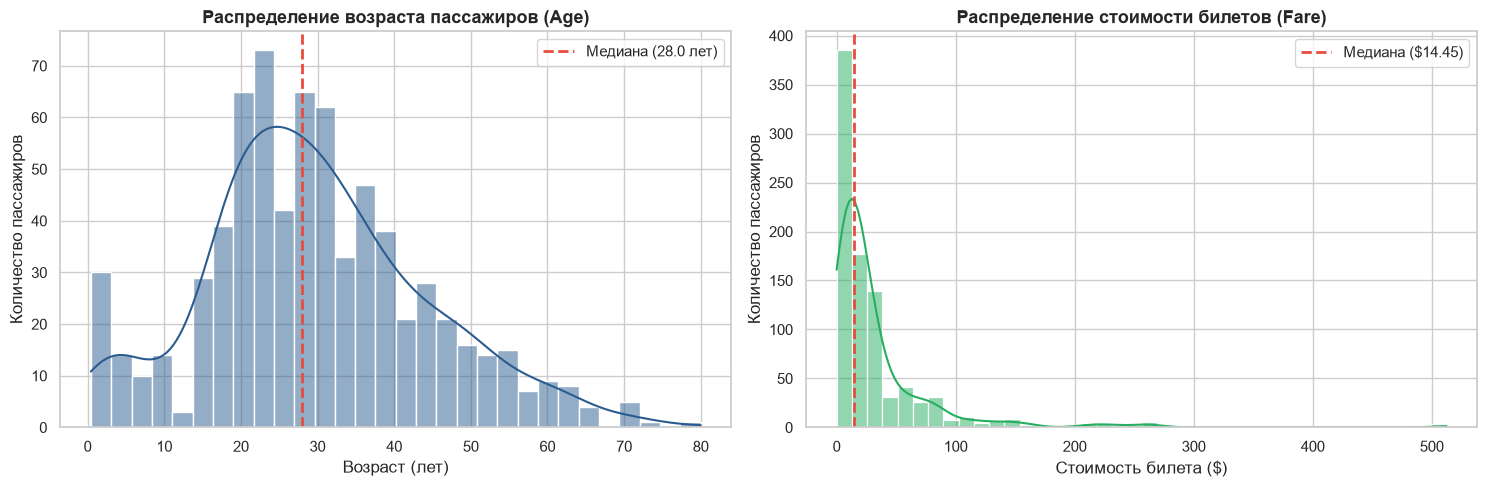

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Гистограмма распределения возраста (Age) с оценкой плотности (KDE)
sns.histplot(df["Age"].dropna(), kde=True, bins=30, ax=axes[0], color="#2b5c8f")
axes[0].set_title("Распределение возраста пассажиров (Age)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Возраст (лет)")
axes[0].set_ylabel("Количество пассажиров")
median_age = df["Age"].median()
axes[0].axvline(median_age, color="#e74c3c", linestyle="--", linewidth=2, label=f"Медиана ({median_age:.1f} лет)")
axes[0].legend()

# 2. Распределение тарифа (Fare) с логарифмической шкалой
sns.histplot(df["Fare"], kde=True, bins=40, ax=axes[1], color="#27ae60")
axes[1].set_title("Распределение стоимости билетов (Fare)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Стоимость билета ($)")
axes[1].set_ylabel("Количество пассажиров")
median_fare = df["Fare"].median()
axes[1].axvline(median_fare, color="#e74c3c", linestyle="--", linewidth=2, label=f"Медиана (${median_fare:.2f})")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2. График 2: Соотношение категорий — Выживаемость по полу (`Sex`) и классам (`Pclass`)

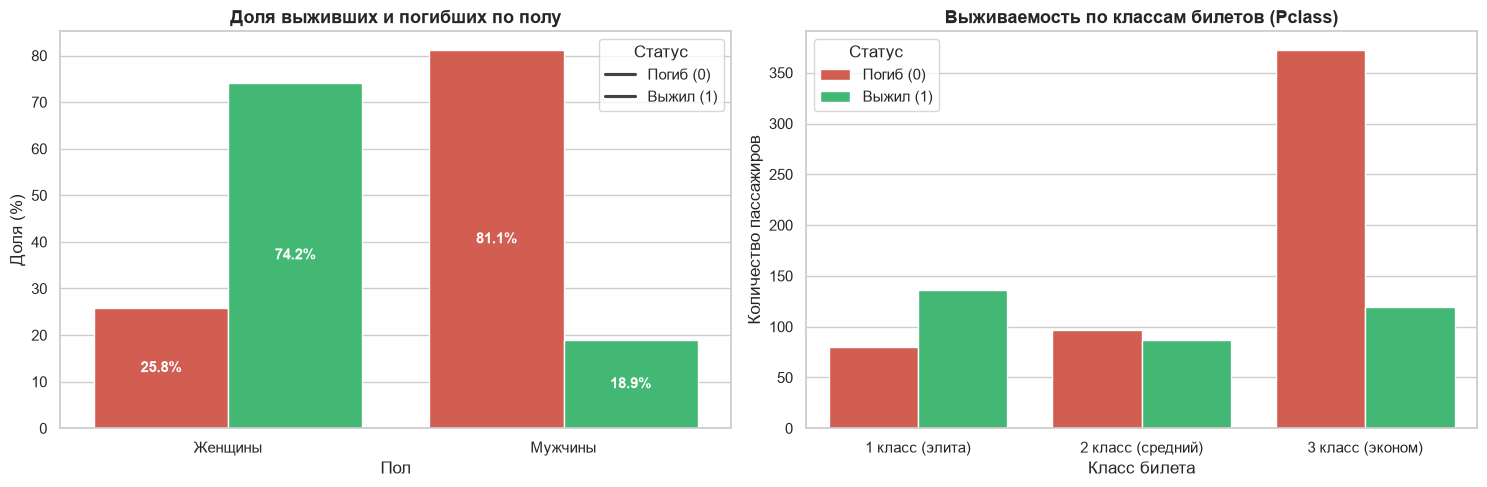

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Соотношение выживших по полу (Sex vs Survived) в процентах
sex_survival = df.groupby("Sex")["Survived"].value_counts(normalize=True).mul(100).rename("Percent").reset_index()
sns.barplot(x="Sex", y="Percent", hue="Survived", data=sex_survival, ax=axes[0], palette=["#e74c3c", "#2ecc71"])
axes[0].set_title("Доля выживших и погибших по полу", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Пол")
axes[0].set_ylabel("Доля (%)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Женщины", "Мужчины"])
axes[0].legend(title="Статус", labels=["Погиб (0)", "Выжил (1)"])

for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.1f}%",
                         (p.get_x() + p.get_width() / 2., h / 2),
                         ha="center", va="center", color="white", fontweight="bold", fontsize=11)

# 2. Количество пассажиров и статус выживания по классам кают (Pclass)
sns.countplot(x="Pclass", hue="Survived", data=df, ax=axes[1], palette=["#e74c3c", "#2ecc71"])
axes[1].set_title("Выживаемость по классам билетов (Pclass)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Класс билета")
axes[1].set_ylabel("Количество пассажиров")
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(["1 класс (элита)", "2 класс (средний)", "3 класс (эконом)"])
axes[1].legend(title="Статус", labels=["Погиб (0)", "Выжил (1)"])

plt.tight_layout()
plt.show()

### 6.3. Дополнительно: Матрица взаимной корреляции числовых признаков

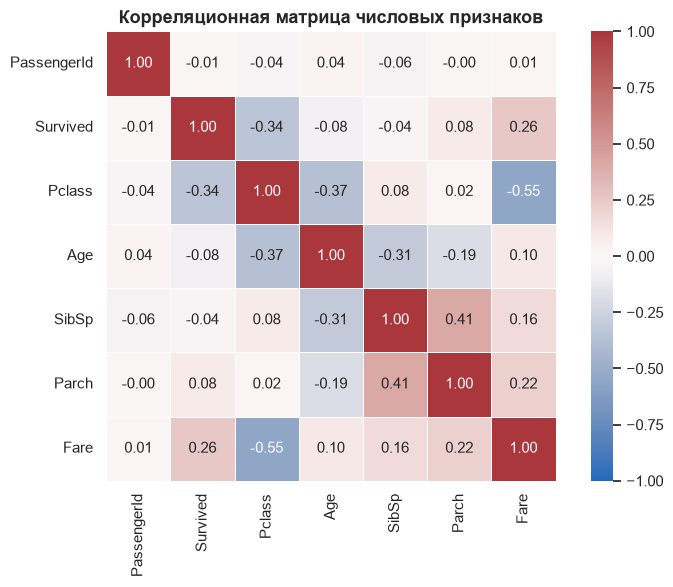

In [8]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".2f", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Корреляционная матрица числовых признаков", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Содержательные наблюдения о данных

В ходе первичного анализа данных сформулированы три ключевых содержательных наблюдения, выходящие за рамки простой статистической сводки метода `describe()`:

1. **Критическое влияние гендерного фактора на выживаемость («женщины и дети в первую очередь»):**
   Несмотря на то, что мужчины составляли подавляющее большинство пассажиров на борту (~64.8%, или 577 из 891 человека), процент выживших среди женщин составил **74.2%**, в то время как среди мужчин спаслись лишь **18.9%**. Это подтверждает строгое соблюдение исторического морского протокола эвакуации и показывает, что признак `Sex` обладает максимальной разделительной способностью для классификации выживаемости.

2. **Выраженное социально-экономическое неравенство и доступ к спасательным средствам:**
   Шансы на спасение напрямую коррелировали с классом обслуживания (`Pclass`): среди пассажиров 1-го класса выжило **62.96%**, во 2-м классе — **47.28%**, а в 3-м классе — всего **24.24%**. Кроме того, признак `Cabin` имеет свыше **77% пропусков**, причем для пассажиров 3-го класса номер каюты не зафиксирован практически в 97% случаев, что указывает на фундаментальные различия в локализации пассажиров на нижних палубах и затрудненность доступа к шлюпочной палубе во время крушения.

3. **Мультимодальность возрастной структуры и защита детской группы:**
   Распределение признака `Age` асимметрично: основная масса пассажиров находилась в молодом трудоспособном возрасте (медиана — 28 лет, интерквартильный размах от 20.1 до 38 лет). Однако на гистограмме отчетливо виден вторичный всплеск в диапазоне от 0 до 5 лет. Детальный срез показывает, что выживаемость среди детей до 5 лет превысила **70%** (даже в низших классах), тогда как пассажиры старше 60 лет имели наименьшую вероятность спасения (<23%), что подчеркивает нелинейный характер связи возраста с целевой переменной.